<a href="https://colab.research.google.com/github/roshika1235/Data_Analysis_Tasks/blob/main/Logistic_regression_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##TASK- Logistic regression   (heart dataset)

## import all necessary libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,accuracy_score
from sklearn.preprocessing import StandardScaler


## explore data, and clean

In [ ]:
df=pd.read_csv('/content/heart.csv')
df

,Unnamed: 0,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


## check for null values , if present remove

In [ ]:
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  303 non-null    int64  
 1   age         303 non-null    int64  
 2   sex         303 non-null    int64  
 3   cp          303 non-null    int64  
 4   trestbps    303 non-null    int64  
 5   chol        303 non-null    int64  
 6   fbs         303 non-null    int64  
 7   restecg     303 non-null    int64  
 8   thalach     303 non-null    int64  
 9   exang       303 non-null    int64  
 10  oldpeak     303 non-null    float64
 11  slope       303 non-null    int64  
 12  ca          303 non-null    int64  
 13  thal        303 non-null    int64  
 14  target      303 non-null    int64  
dtypes: float64(1), int64(14)
memory usage: 35.6 KB


In [ ]:
# df=df.groupby("sex")["target"].value_counts()
# df


## EDA, visualize data

<Axes: xlabel='sex', ylabel='Count'>

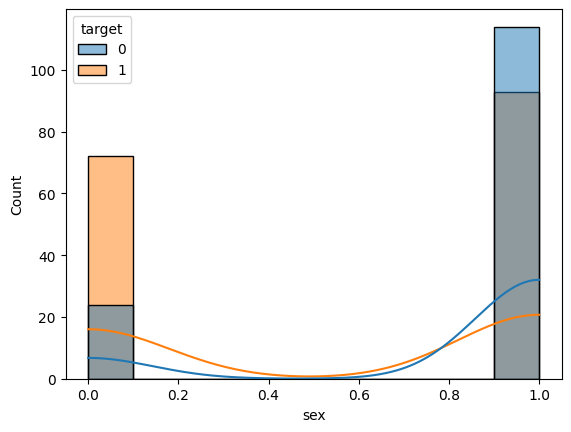

In [ ]:
sns.histplot(x="sex",data=df,hue='target',kde=True)

## female are more who are diagnosed with cancer

<Axes: xlabel='chol', ylabel='Count'>

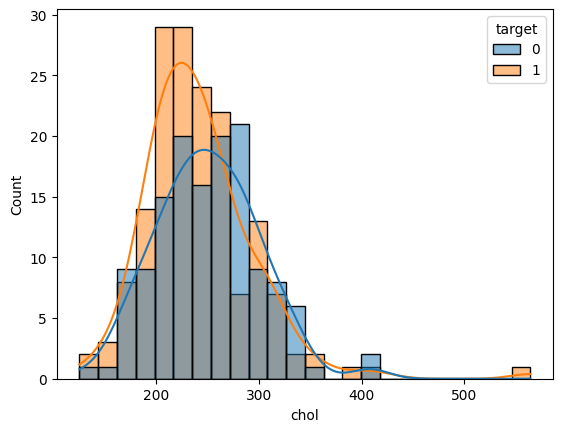

In [ ]:
sns.histplot(x="chol",data=df,hue='target',kde=True)

## the above histplot , gives insights, if chlorestor is more prediction of cancer is positive

<Axes: xlabel='age', ylabel='Count'>

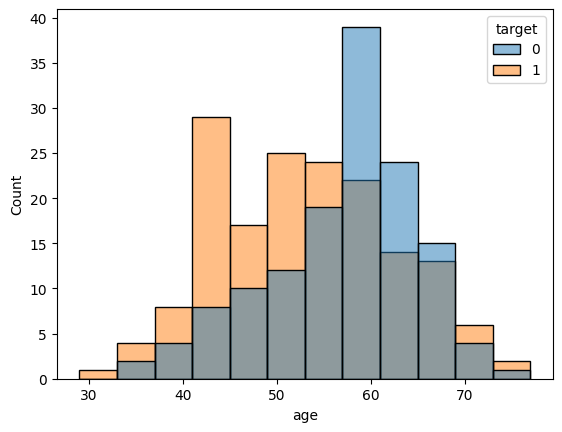

In [ ]:
sns.histplot(x="age",data=df,hue='target')

## Age group of 42- 55 having cancer mostly

## separate X columns and target

In [ ]:
x=df.drop('target',axis=1)
y=df['target']

## according to ML rules ,  divide 70 % of data for training and 30% for testing

In [ ]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=42)    # to avoid random sampling put random_state=42


## Load model

In [ ]:
model=LogisticRegression()
model.fit(xtrain,ytrain)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

## prediction

In [ ]:
ypred=model.predict(xtest)
ypred

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 1])

## performance metrics of Logistic Regression

In [ ]:
confusion_matrix(ytest,ypred)

array([[40,  1],
       [ 1, 49]])

In [ ]:
print("classfication_report: ",classification_report(ytest,ypred))

classfication_report:                precision    recall  f1-score   support

           0       0.98      0.98      0.98        41
           1       0.98      0.98      0.98        50

    accuracy                           0.98        91
   macro avg       0.98      0.98      0.98        91
weighted avg       0.98      0.98      0.98        91



In [ ]:
print("total_eff: ",model.score(xtrain,ytrain))
print("total_eff: ",model.score(xtest,ytest))

total_eff:  1.0
total_eff:  0.978021978021978


## actual prediction

In [ ]:
print("accuracy score: ",accuracy_score(ytest,ypred))

accuracy score:  0.978021978021978


## prediction of new data

In [ ]:
new_data=df.iloc[78:79 ,:-1]
pred=model.predict(new_data)
if pred==1:
  print("heart disease")
else:
  print("no heart disease")

heart disease
